In [1]:
%reload_ext autoreload
%autoreload 2

# nasa-impact/nasa-smd-IR-benchmark 

In [2]:
from datasets import load_dataset, concatenate_datasets
from huggingface_hub import hf_hub_download
import json
import pandas as pd
from datasets import Dataset, DatasetDict


dataset = load_dataset("nasa-impact/nasa-smd-IR-benchmark")
dataset = concatenate_datasets(list(dataset.values()))

df = dataset.to_pandas()

df.head()


/rhome/sawale/miniconda3/envs/slurm-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,query-id,corpus-id,score
0,67,72915,1
1,239,37223,1
2,495,250048,1
3,283,125841,1
4,200,213374,1


In [3]:
# Download queries.jsonl from the dataset repo
queries_path = hf_hub_download(
    repo_id="nasa-impact/nasa-smd-IR-benchmark",
    filename="queries.jsonl",
    repo_type="dataset"
)

# Download corpus.jsonl similarly
corpus_path = hf_hub_download(
    repo_id="nasa-impact/nasa-smd-IR-benchmark",
    filename="corpus.jsonl",
    repo_type="dataset"
)

queries_df = pd.read_json(queries_path, lines=True)
queries_df.rename(columns={"_id": "query-id", "text": "query"}, inplace=True)

corpus_df = pd.read_json(corpus_path, lines=True)
corpus_df.rename(columns={"_id": "corpus-id", "text": "corpus"}, inplace=True)

# Join for validation set
df = df.merge(queries_df, on="query-id", how="left")
df = df.merge(corpus_df, on="corpus-id", how="left")
df.rename({"query": "anchor", "corpus": "positive"}, axis=1, inplace=True)
df = df[["anchor", "positive"]]
df.head()


hf_ds = Dataset.from_pandas(df, preserve_index=False)
hf_dd = DatasetDict({"nasa-smd-IR-benchmark": hf_ds})

In [10]:
from sentence_transformers import SentenceTransformer

modernbert_model_before_traning = SentenceTransformer("nomic-ai/modernbert-embed-base")
indus_st_v2_model_before_traning = SentenceTransformer("nasa-impact/nasa-smd-ibm-st-v2")

modernbert_model = SentenceTransformer("/rhome/sawale/indus_traning/sentense_transformers/model_exploration/tmp_models/nrows_100__nsrc_None/timestamp_20250512_13-45-10/modernbert-embed-base/checkpoints/checkpoint-1300")
indus_st_v2_model = SentenceTransformer("/rhome/sawale/indus_traning/sentense_transformers/model_exploration/tmp_models/nrows_100__nsrc_None/timestamp_20250512_13-49-27/nasa-smd-ibm-st-v2/checkpoints/checkpoint-1300")
indus_sde_v2_st_model = SentenceTransformer("/rhome/sawale/indus_traning/sentense_transformers/model_exploration/tmp_models/nrows_None__nsrc_None/timestamp_20250505_16-10-36/indus-sde-v0.2/checkpoints/checkpoint-115000")


models = {
    "ModernBERT_ST_original": modernbert_model_before_traning,
    "Indus_ST_original": indus_st_v2_model_before_traning,
    "ModernBERT_ST_fine_tuned": modernbert_model,
    "Indus_ST_fine_tuned": indus_st_v2_model,
    "Indus_SDE_ST_intermediate_checkpoint_115k": indus_sde_v2_st_model
}

In [ ]:
from utils import prepare_evaluators

evaluator = prepare_evaluators(hf_dd, max_per_split=None)
evals = {m_str: evaluator(m)  for m_str, m in models.items() }

Prepared SequentialEvaluator with: ['ir_evaluator', 'mnr_loss']


Corpus Chunks: 100%|██████████| 1/1 [00:34<00:00, 34.45s/it]


## Retrival Time evals

In [ ]:
from utils import RetrievalTimer
time_reports = {m_str: RetrievalTimer(m, corpus=hf_ds["positive"], queries=hf_ds["anchor"], top_k=10).run()  for m_str, m in models.items() }
evals = {m_str: {**evals[m_str], **time_reports[m_str]} for m_str in evals.keys()}

In [ ]:
evals["Indus_ST_original"]

{'ir_evaluator_cosine_accuracy@1': 0.25301204819277107,
 'ir_evaluator_cosine_accuracy@5': 0.7971887550200804,
 'ir_evaluator_cosine_accuracy@10': 0.8493975903614458,
 'ir_evaluator_cosine_precision@1': 0.25301204819277107,
 'ir_evaluator_cosine_precision@5': 0.15943775100401605,
 'ir_evaluator_cosine_precision@10': 0.08493975903614458,
 'ir_evaluator_cosine_recall@1': 0.25301204819277107,
 'ir_evaluator_cosine_recall@5': 0.7971887550200804,
 'ir_evaluator_cosine_recall@10': 0.8493975903614458,
 'ir_evaluator_cosine_ndcg@1': 0.25301204819277107,
 'ir_evaluator_cosine_ndcg@5': 0.5498379932558063,
 'ir_evaluator_cosine_ndcg@10': 0.5672590785265158,
 'ir_evaluator_cosine_mrr@1': 0.25301204819277107,
 'ir_evaluator_cosine_mrr@5': 0.4663989290495321,
 'ir_evaluator_cosine_mrr@10': 0.4739099254159502,
 'ir_evaluator_cosine_map@1': 0.25301204819277107,
 'ir_evaluator_cosine_map@5': 0.46639892904953145,
 'ir_evaluator_cosine_map@10': 0.4739099254159495,
 'mnr_loss/avg': 1.4328865483403206,
 'm

In [ ]:
print(evals)

{'ModernBERT_ST_original': {'ir_evaluator_cosine_accuracy@1': 0.26706827309236947, 'ir_evaluator_cosine_accuracy@5': 0.8353413654618473, 'ir_evaluator_cosine_accuracy@10': 0.9036144578313253, 'ir_evaluator_cosine_precision@1': 0.26706827309236947, 'ir_evaluator_cosine_precision@5': 0.1670682730923695, 'ir_evaluator_cosine_precision@10': 0.09036144578313253, 'ir_evaluator_cosine_recall@1': 0.26706827309236947, 'ir_evaluator_cosine_recall@5': 0.8353413654618473, 'ir_evaluator_cosine_recall@10': 0.9036144578313253, 'ir_evaluator_cosine_ndcg@1': 0.26706827309236947, 'ir_evaluator_cosine_ndcg@5': 0.5839296131091536, 'ir_evaluator_cosine_ndcg@10': 0.6067956965836963, 'ir_evaluator_cosine_mrr@1': 0.26706827309236947, 'ir_evaluator_cosine_mrr@5': 0.4985274431057573, 'ir_evaluator_cosine_mrr@10': 0.5084217823675662, 'ir_evaluator_cosine_map@1': 0.26706827309236947, 'ir_evaluator_cosine_map@5': 0.4985274431057563, 'ir_evaluator_cosine_map@10': 0.5084217823675655, 'mnr_loss/avg': 1.37944649904966

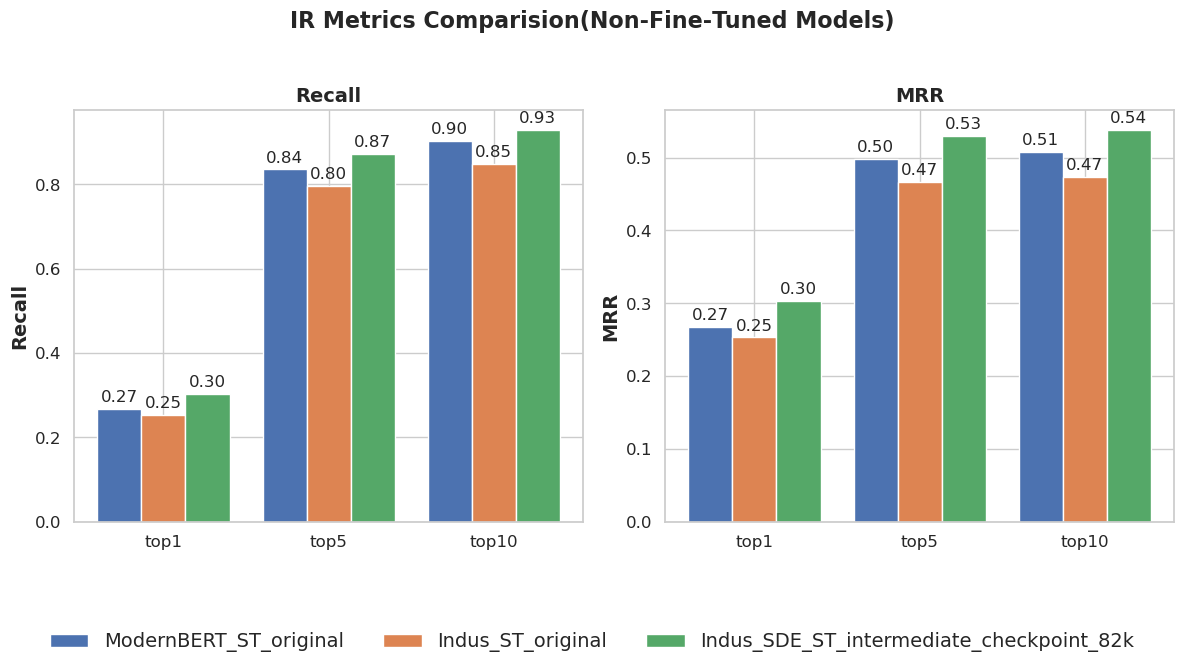

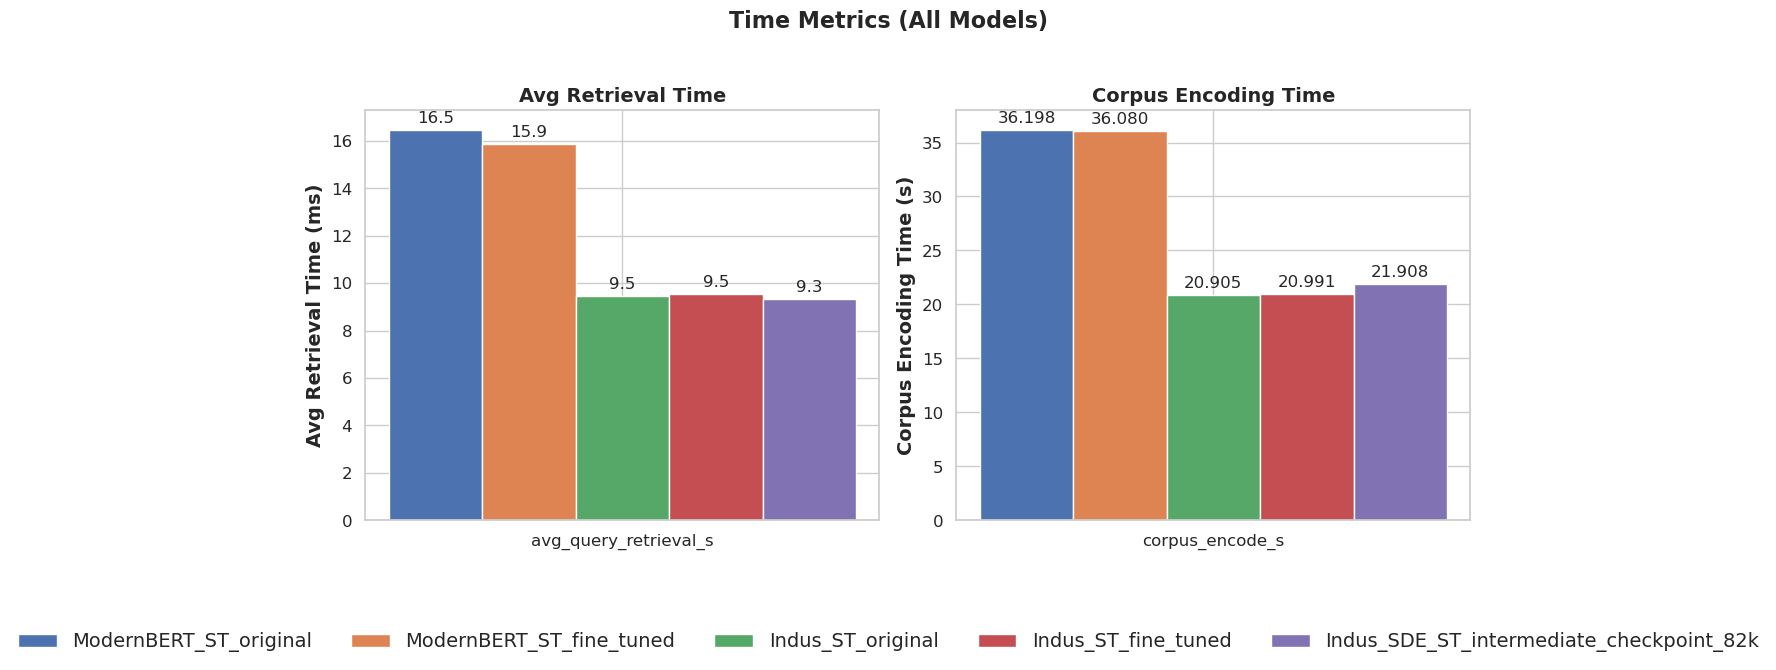

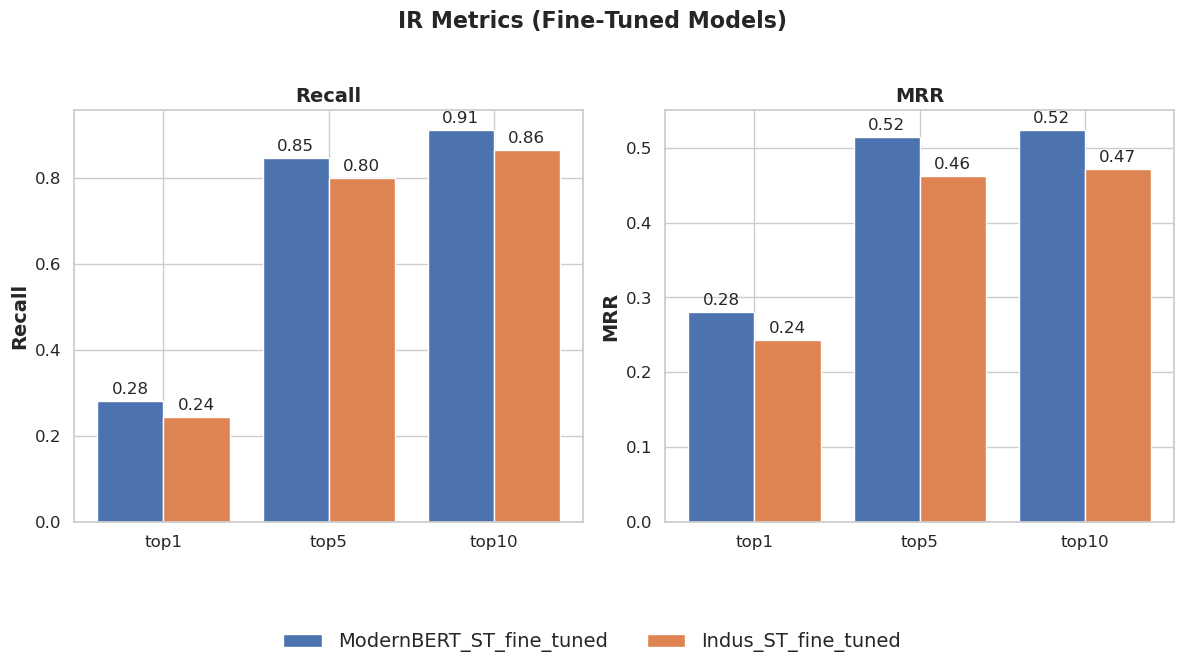

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─── Settings ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="deep")
FONT_SIZE = 14
TICK_FONT_SIZE = FONT_SIZE - 2

# ─── 1) Specify exact model order ────────────────────────────────────────────
desired_order = [
    'indus_st_v2_original',
    'indus_st_v2_fine_tuned',
    'modernbert_st_original',
    'modernbert_st_fine_tuned',
    'indus_sde_based'
]
model_names = []
for name in desired_order:
    for real in evals:
        if real.lower() == name.lower():
            model_names.append(real)
            break
for real in evals:
    if real not in model_names:
        model_names.append(real)

non_finetuned_models = [m for m in model_names if 'fine_tuned' not in m.lower()]
finetuned_models    = [m for m in model_names if 'fine_tuned' in m.lower()]

# ─── 2) Define metric groups (MAP removed) ───────────────────────────────────
main_metric_groups = {
    'Recall': sorted(
        [k for k in evals[model_names[0]] if 'recall' in k],
        key=lambda x: int(x.split('@')[1])
    ),
    'MRR': sorted(
        [k for k in evals[model_names[0]] if 'mrr' in k],
        key=lambda x: int(x.split('@')[1])
    )
}
time_metric_groups = {
    'Avg Retrieval Time':   ['avg_query_retrieval_s'],
    'Corpus Encoding Time': ['corpus_encode_s']
}

# ─── 3) Plot 1: Main metrics for non-fine-tuned models ───────────────────────
fig1, axes1 = plt.subplots(1, len(main_metric_groups), figsize=(6 * len(main_metric_groups), 6), squeeze=False)
axes1 = axes1[0]
for ax, (title, keys) in zip(axes1, main_metric_groups.items()):
    idx = np.arange(len(keys))
    width = 0.8 / len(non_finetuned_models)
    for i, m in enumerate(non_finetuned_models):
        vals = [evals[m][k] for k in keys]
        bars = ax.bar(idx + i * width, vals, width, label=m)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=TICK_FONT_SIZE)
    ax.set_title(title,       fontsize=FONT_SIZE,   fontweight='bold')
    ax.set_ylabel(title,      fontsize=FONT_SIZE,   fontweight='bold')
    ax.set_xticks(idx + width*(len(non_finetuned_models)-1)/2)
    ax.set_xticklabels([f"top{k.split('@')[-1]}" for k in keys], fontsize=TICK_FONT_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

leg1 = fig1.legend(non_finetuned_models, loc='lower center', ncol=len(non_finetuned_models),
                   bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZE, frameon=False)
leg1.set_title("")
fig1.suptitle("IR Metrics Comparision(Non‑Fine‑Tuned Models)", fontsize=FONT_SIZE+2, fontweight='bold')
fig1.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ─── 4) Plot 2: Time metrics for all models (retrieval in ms) ───────────────
fig2, axes2 = plt.subplots(1, len(time_metric_groups), figsize=(6 * len(time_metric_groups), 6), squeeze=False)
axes2 = axes2[0]
for ax, (title, keys) in zip(axes2, time_metric_groups.items()):
    idx = np.arange(len(keys))
    width = 0.8 / len(model_names)
    for i, m in enumerate(model_names):
        if title == 'Avg Retrieval Time':
            vals = [evals[m][k] * 1000 for k in keys]  # seconds→ms
            fmt = "%.1f"
            unit = "ms"
        else:
            vals = [evals[m][k] for k in keys]
            fmt = "%.3f"
            unit = "s"
        bars = ax.bar(idx + i * width, vals, width, label=m)
        ax.bar_label(bars, fmt=fmt, padding=3, fontsize=TICK_FONT_SIZE)
    ax.set_title(title,       fontsize=FONT_SIZE,   fontweight='bold')
    ax.set_ylabel(f"{title} ({unit})", fontsize=FONT_SIZE, fontweight='bold')
    ax.set_xticks(idx + width*(len(model_names)-1)/2)
    ax.set_xticklabels(keys, fontsize=TICK_FONT_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

leg2 = fig2.legend(model_names, loc='lower center', ncol=len(model_names),
                   bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZE, frameon=False)
leg2.set_title("")
fig2.suptitle("Time Metrics (All Models)", fontsize=FONT_SIZE+2, fontweight='bold')
fig2.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ─── 5) Plot 3: Main metrics for fine-tuned models ───────────────────────────
if finetuned_models:
    fig3, axes3 = plt.subplots(1, len(main_metric_groups), figsize=(6 * len(main_metric_groups), 6), squeeze=False)
    axes3 = axes3[0]
    for ax, (title, keys) in zip(axes3, main_metric_groups.items()):
        idx = np.arange(len(keys))
        width = 0.8 / len(finetuned_models)
        for i, m in enumerate(finetuned_models):
            vals = [evals[m][k] for k in keys]
            bars = ax.bar(idx + i * width, vals, width, label=m)
            ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=TICK_FONT_SIZE)
        ax.set_title(title,       fontsize=FONT_SIZE,   fontweight='bold')
        ax.set_ylabel(title,      fontsize=FONT_SIZE,   fontweight='bold')
        ax.set_xticks(idx + width*(len(finetuned_models)-1)/2)
        ax.set_xticklabels([f"top{k.split('@')[-1]}" for k in keys], fontsize=TICK_FONT_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

    leg3 = fig3.legend(finetuned_models, loc='lower center', ncol=len(finetuned_models),
                       bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZE, frameon=False)
    leg3.set_title("")
    fig3.suptitle("IR Metrics (Fine‑Tuned Models)", fontsize=FONT_SIZE+2, fontweight='bold')
    fig3.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
